In [ ]:
#Bibliothèques
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1_Exploration du dataset


In [ ]:
# Charger le dataset
data = pd.read_csv("/content/train_test_network.csv")

# Afficher les premières lignes
print(data.head())

          src_ip  src_port         dst_ip  dst_port proto service    duration  \
0   192.168.1.37      4444  192.168.1.193     49178   tcp       -  290.371539   
1  192.168.1.193     49180   192.168.1.37      8080   tcp       -    0.000102   
2  192.168.1.193     49180   192.168.1.37      8080   tcp       -    0.000148   
3  192.168.1.193     49180   192.168.1.37      8080   tcp       -    0.000113   
4  192.168.1.193     49180   192.168.1.37      8080   tcp       -    0.000130   

   src_bytes  dst_bytes conn_state  ...  http_response_body_len  \
0     101568       2592        OTH  ...                       0   
1          0          0        REJ  ...                       0   
2          0          0        REJ  ...                       0   
3          0          0        REJ  ...                       0   
4          0          0        REJ  ...                       0   

   http_status_code  http_user_agent  http_orig_mime_types  \
0                 0                -            

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

In [ ]:
#Afficher les descriptions des informations
print(data.describe())

            src_port       dst_port       duration     src_bytes  \
count  211043.000000  211043.000000  211043.000000  2.110430e+05   
mean    38646.519543    3495.153770       7.700887  2.581136e+05   
std     19307.271048   10191.624778     564.141946  1.709490e+07   
min         1.000000       0.000000       0.000000  0.000000e+00   
25%     34608.000000      65.000000       0.000000  0.000000e+00   
50%     44754.000000      80.000000       0.000170  0.000000e+00   
75%     51133.000000    1253.000000       0.054196  1.300000e+02   
max     65528.000000   65467.000000   93516.929170  3.890855e+09   

          dst_bytes  missed_bytes       src_pkts  src_ip_bytes       dst_pkts  \
count  2.110430e+05  2.110430e+05  211043.000000  2.110430e+05  211043.000000   
mean   2.588046e+05  3.443234e+04       9.595220  7.760822e+02       3.846861   
std    1.802563e+07  5.261621e+06      91.778821  2.229703e+04     330.705796   
min    0.000000e+00  0.000000e+00       0.000000  0.000000e+00 

a. Explorez votre dataset à l'aide de visualisations (graphiques, histogrammes, etc.).

<ipython-input-5-db59c0949535>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='label', palette='Set2')


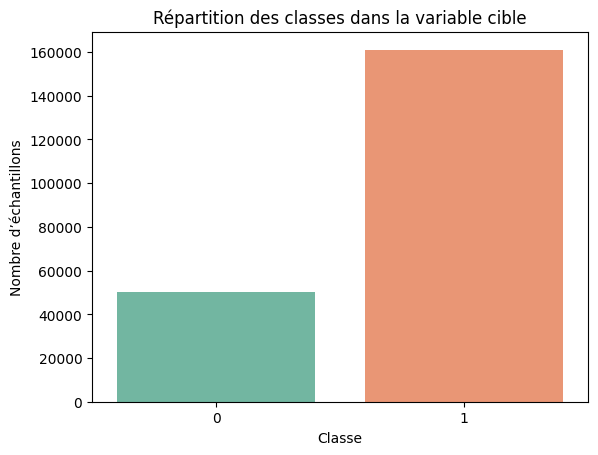

In [ ]:
#Distribution de la variable label
sns.countplot(data=data, x='label', palette='Set2')
plt.title('Répartition des classes dans la variable cible')
plt.xlabel('Classe')
plt.ylabel('Nombre d’échantillons')
plt.show()


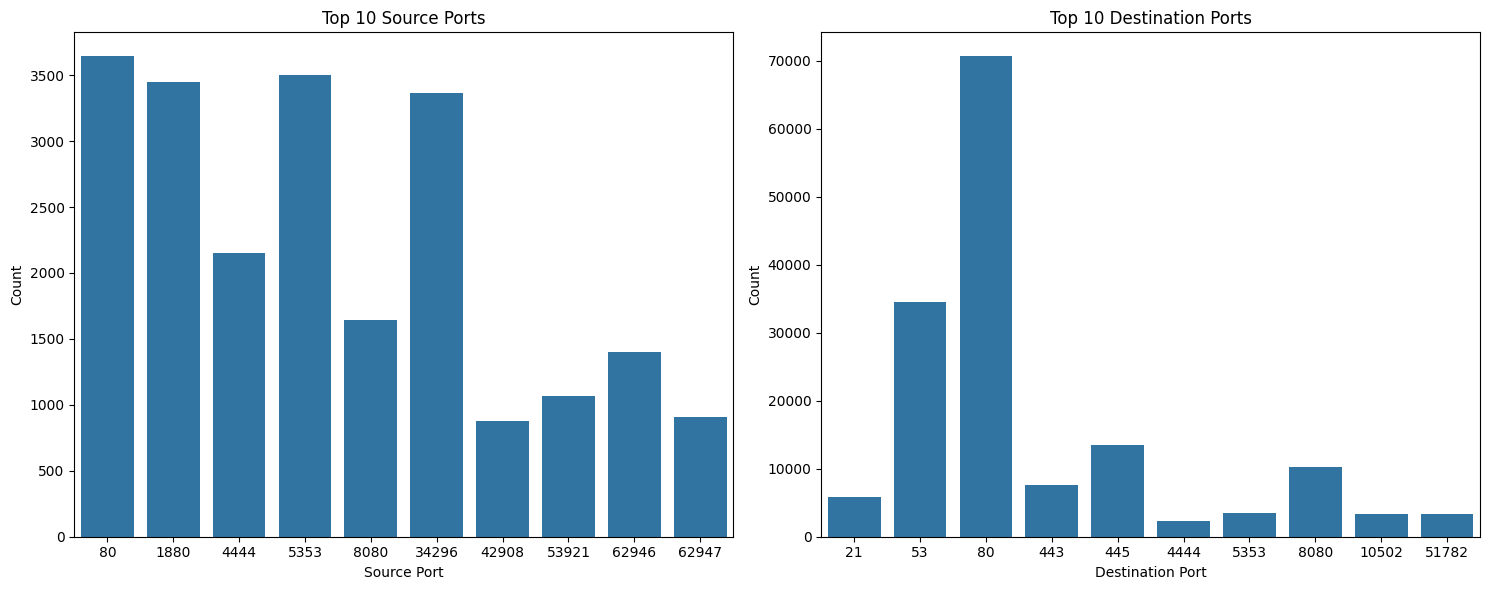

In [ ]:
# Top 10 source ports
top_src_ports = data['src_port'].value_counts().nlargest(10)
top_dst_ports = data['dst_port'].value_counts().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=top_src_ports.index, y=top_src_ports.values, ax=axes[0])
axes[0].set_title('Top 10 Source Ports')
axes[0].set_xlabel('Source Port')
axes[0].set_ylabel('Count')

sns.barplot(x=top_dst_ports.index, y=top_dst_ports.values, ax=axes[1])
axes[1].set_title('Top 10 Destination Ports')
axes[1].set_xlabel('Destination Port')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


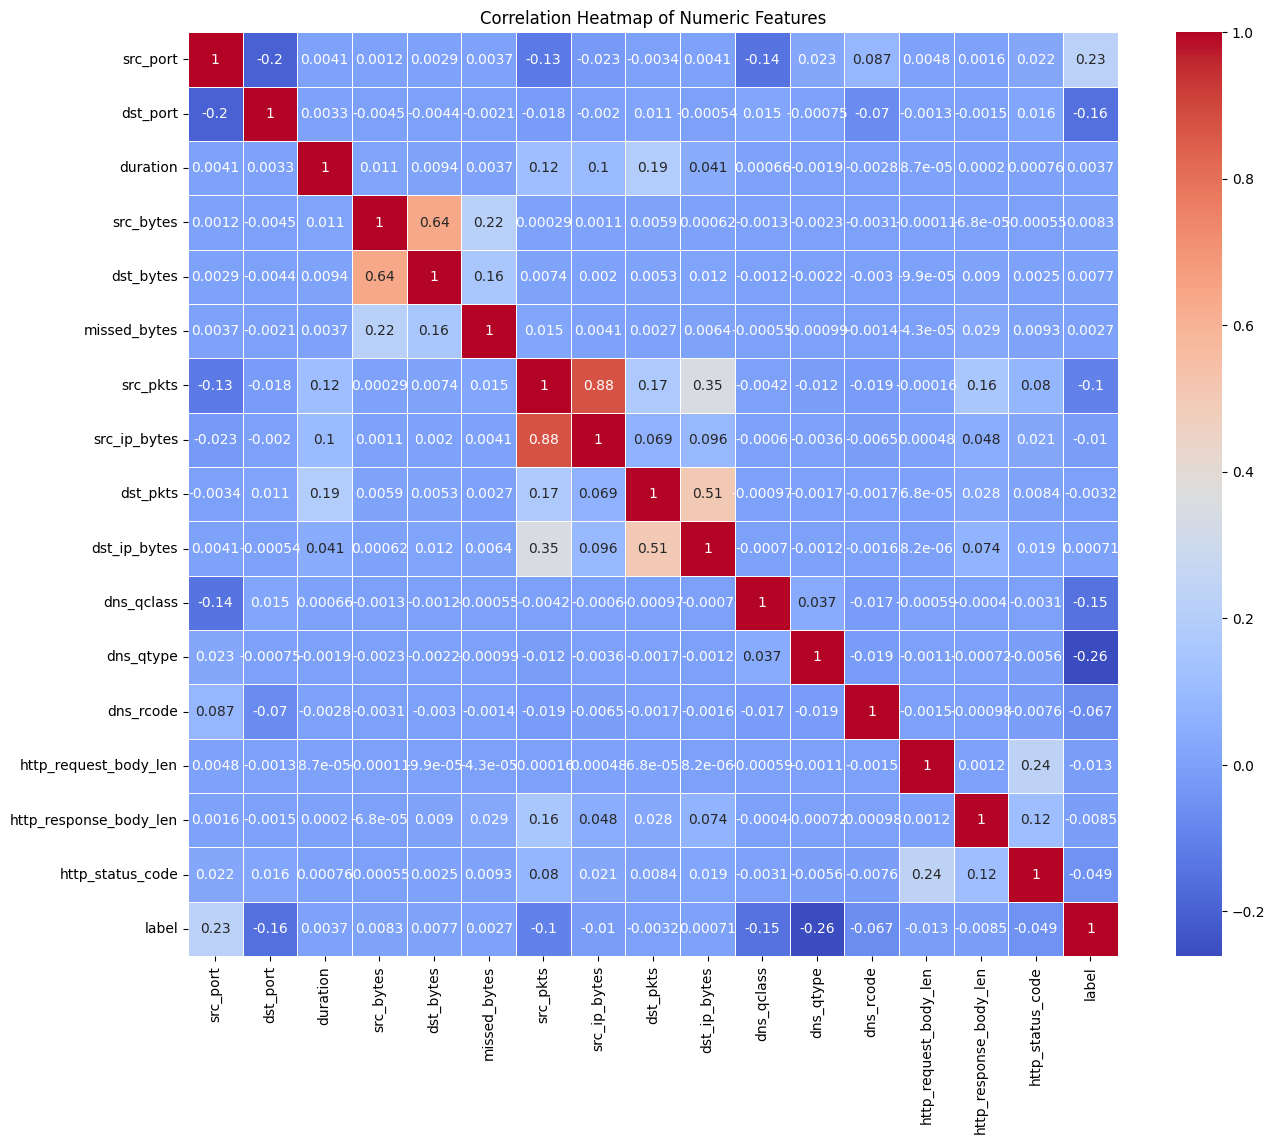

In [ ]:
import numpy as np

plt.figure(figsize=(15, 12))
numeric_features = data.select_dtypes(include=[np.number])
correlation = numeric_features.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


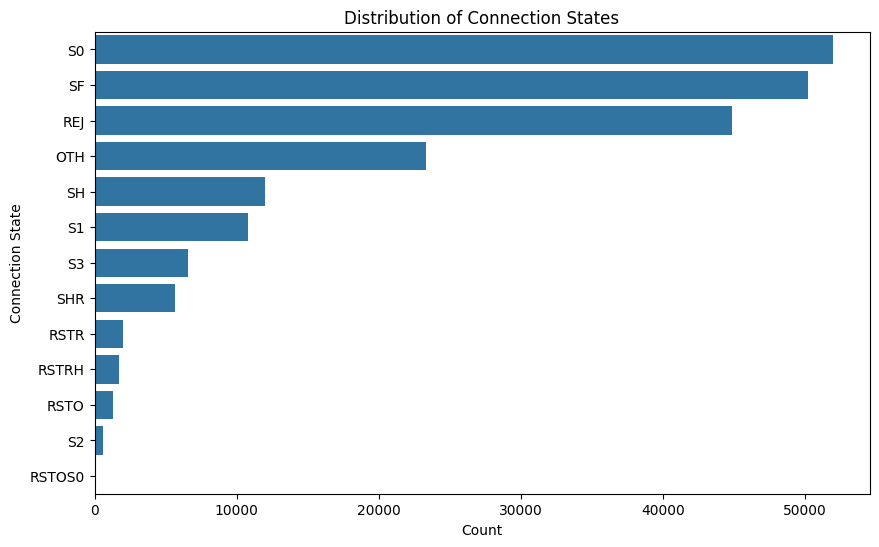

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='conn_state', data=data, order=data['conn_state'].value_counts().index)
plt.title('Distribution of Connection States')
plt.xlabel('Count')
plt.ylabel('Connection State')
plt.show()


<ipython-input-15-d86700dcdba5>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=protocol_counts.index, y=protocol_counts.values, palette='viridis')


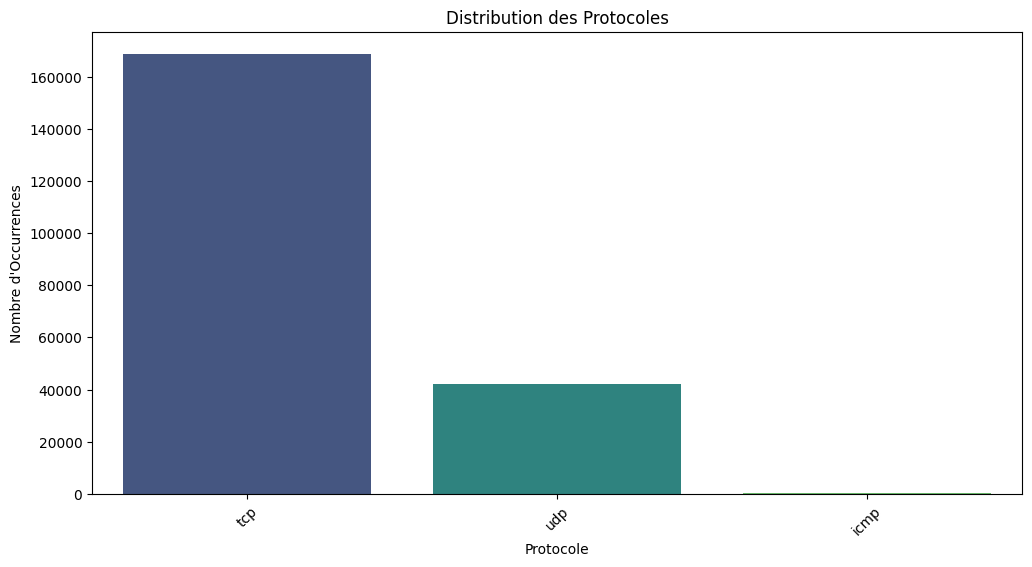

In [ ]:
protocol_counts = data['proto'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=protocol_counts.index, y=protocol_counts.values, palette='viridis')
plt.title('Distribution des Protocoles')
plt.xlabel('Protocole')
plt.ylabel('Nombre d\'Occurrences')
plt.xticks(rotation=45)  # Rotation des étiquettes pour une meilleure lisibilité
plt.show()


<ipython-input-17-65e48f6f059f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='duration', data=data, palette='Set2')


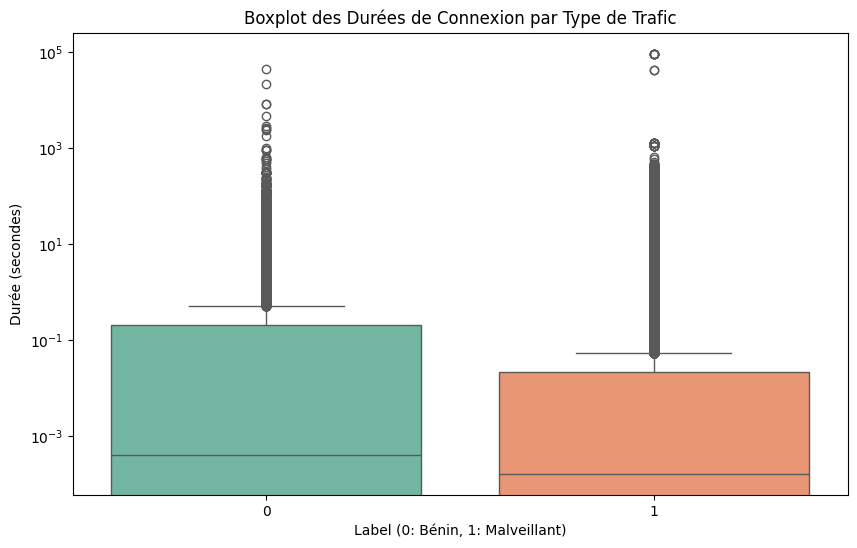

In [ ]:
plt.figure(figsize=(10, 6))

# Créer le boxplot pour les durées par label
sns.boxplot(x='label', y='duration', data=data, palette='Set2')
plt.title('Boxplot des Durées de Connexion par Type de Trafic')
plt.xlabel('Label (0: Bénin, 1: Malveillant)')
plt.ylabel('Durée (secondes)')
plt.yscale('log')  # Utiliser une échelle logarithmique pour mieux visualiser les valeurs

plt.show()


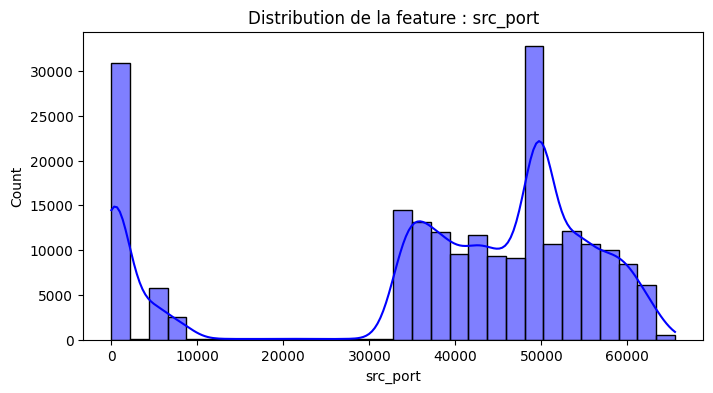

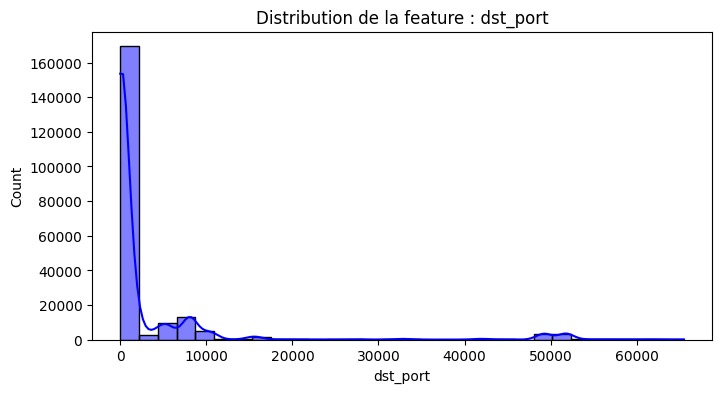

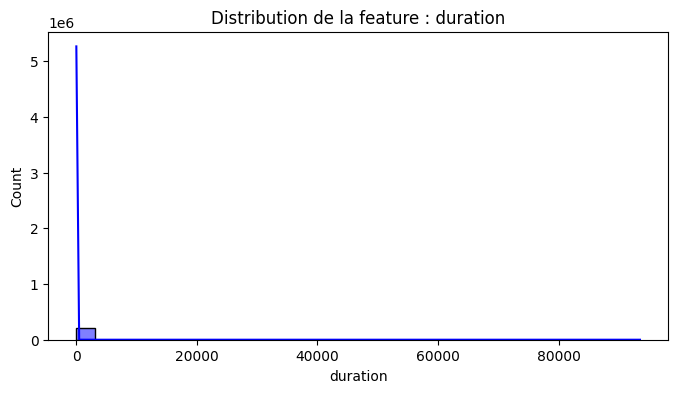

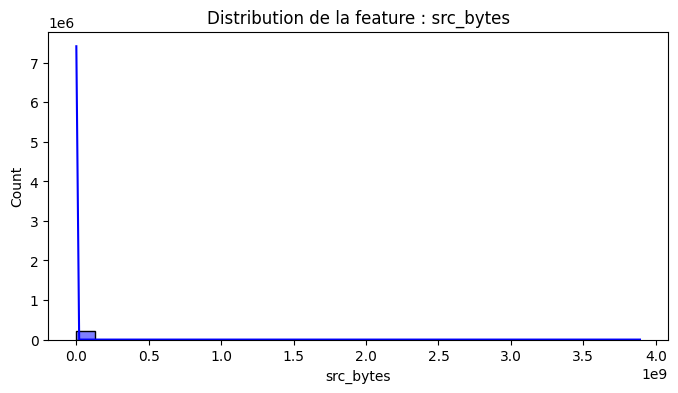

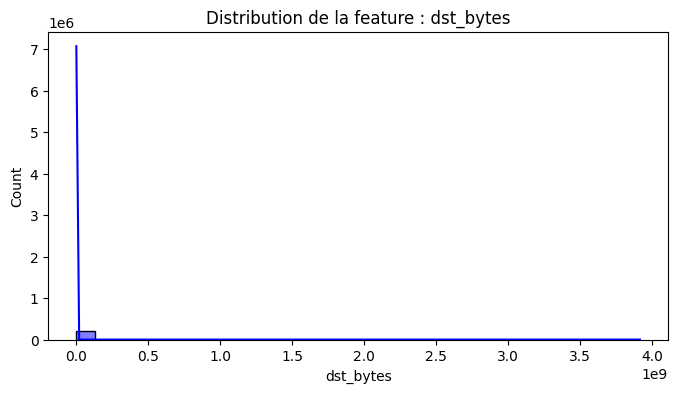

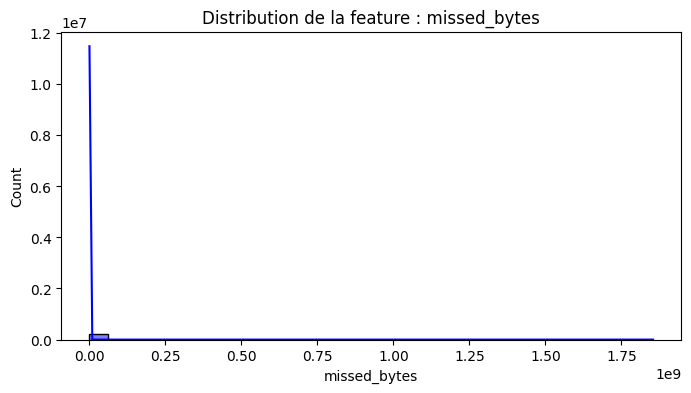

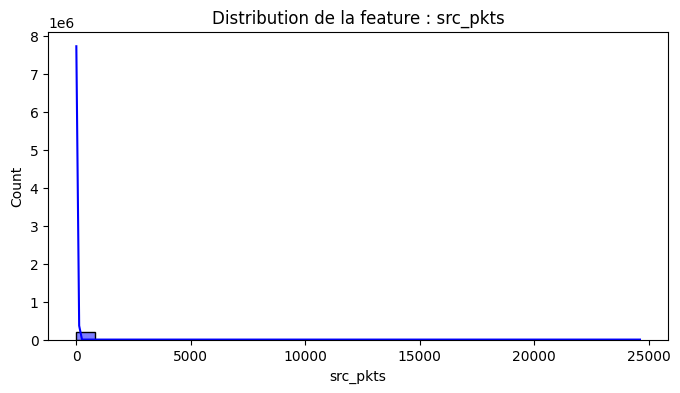

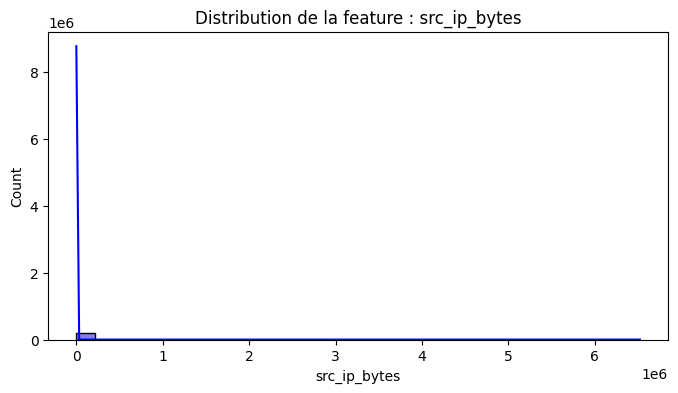

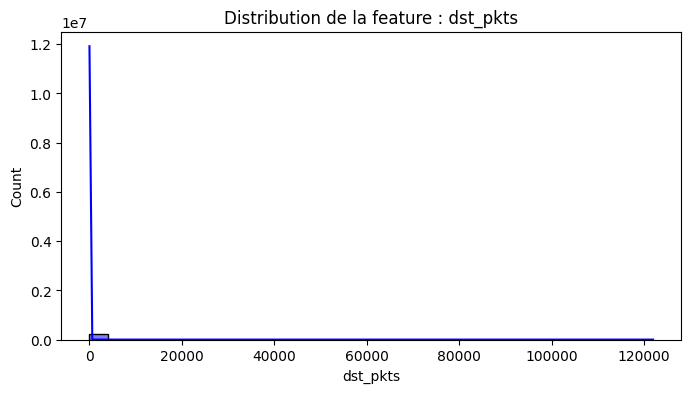

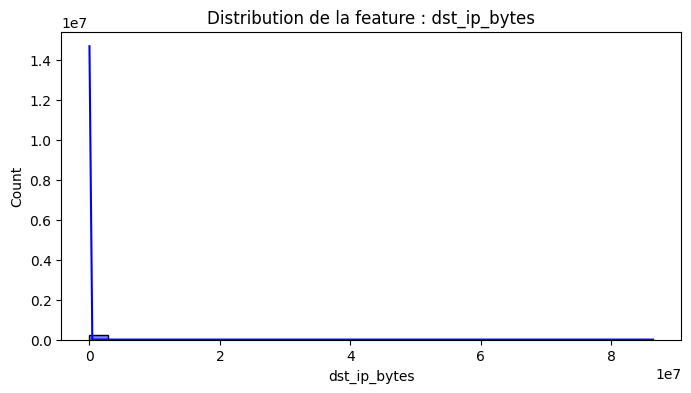

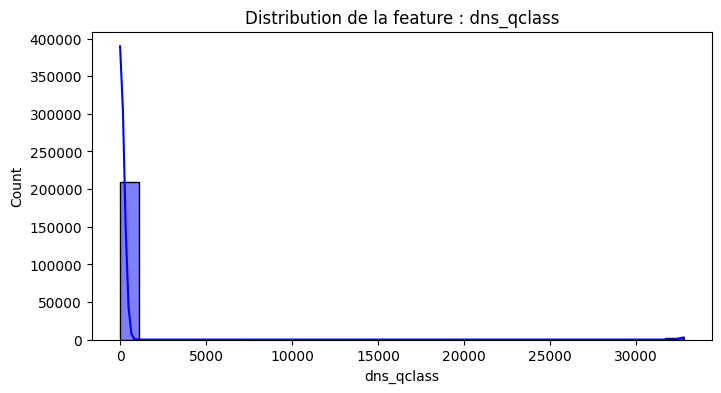

KeyboardInterrupt: 

<Figure size 800x400 with 0 Axes>

In [ ]:
#Analyse des features numériques
numeric = data.select_dtypes(include=['float64', 'int64'])
for col in numeric.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[col], kde=True, bins=30, color='blue')
    plt.title(f'Distribution de la feature : {col}')
    plt.show()


In [ ]:
#Analyse des features catégorielles
categorical = data.select_dtypes(include=['object', 'category'])
for col in categorical.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, hue=None, palette='Set3', legend=False)
    plt.title(f'Distribution de la feature catégorielle : {col}')
    plt.xticks(rotation=45)
    plt.show()



In [ ]:
#Identifiez des tendances, des anomalies ou des patterns intéressants
numeric = data.select_dtypes(include=['float64', 'int64'])
for col in numeric.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data['label'], y=data[col], palette='husl', hue=None)
    plt.title(f'Relation entre {col} et label')
    plt.show()


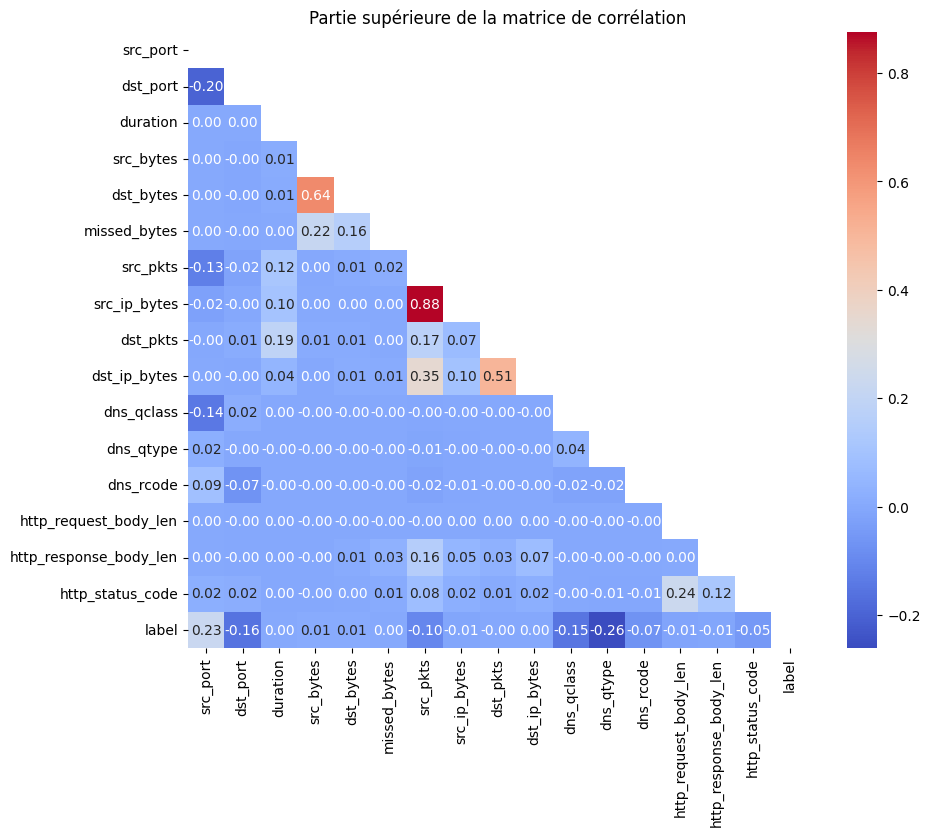

In [ ]:
#Corrélations globales
plt.figure(figsize=(10, 8))
corr = numeric.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('Partie supérieure de la matrice de corrélation')
plt.show()


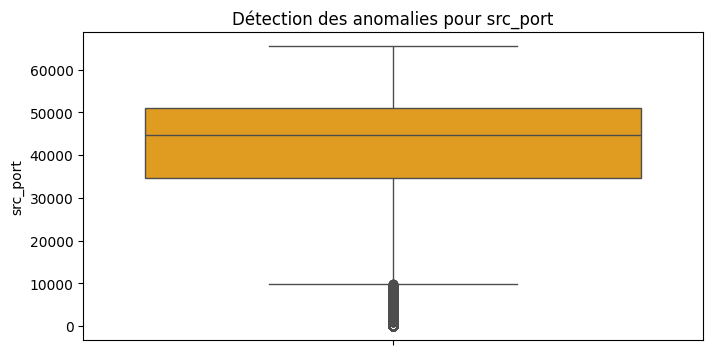

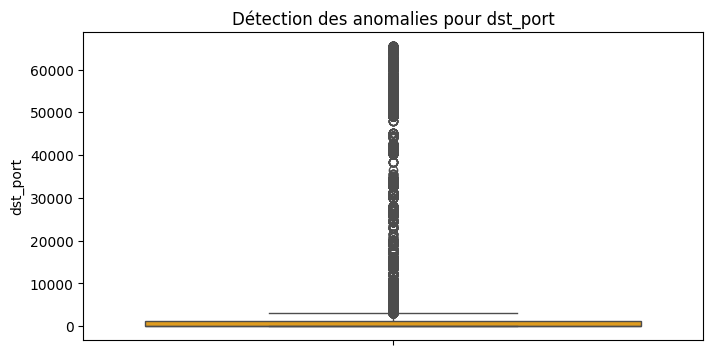

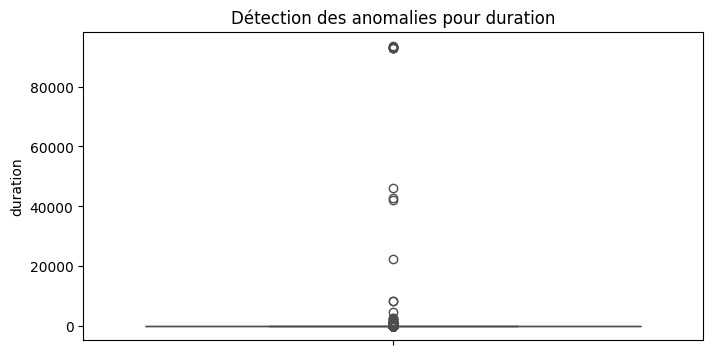

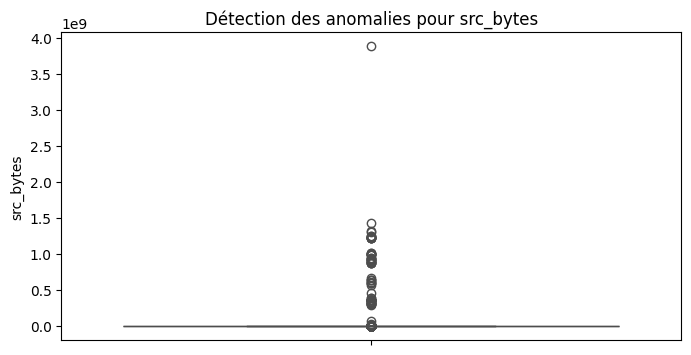

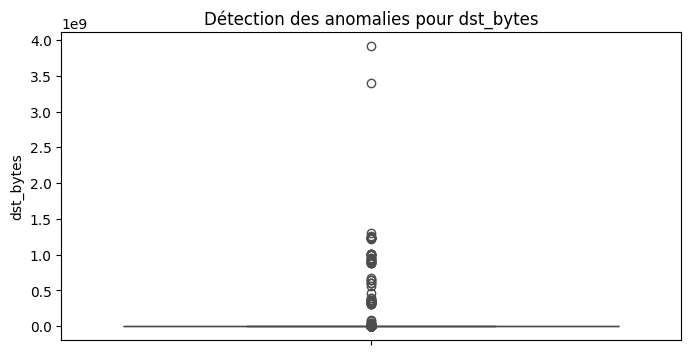

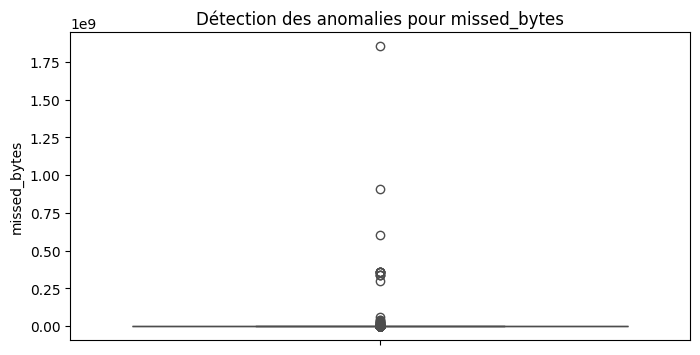

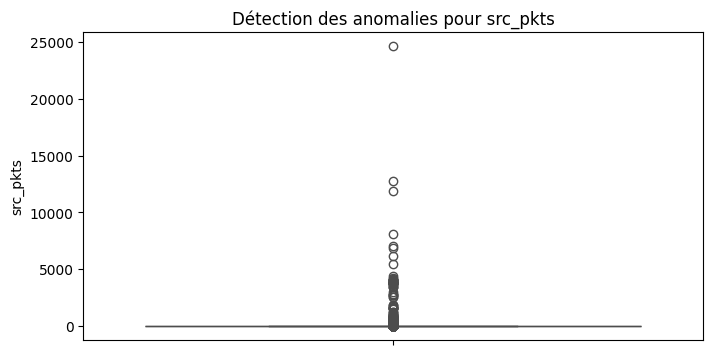

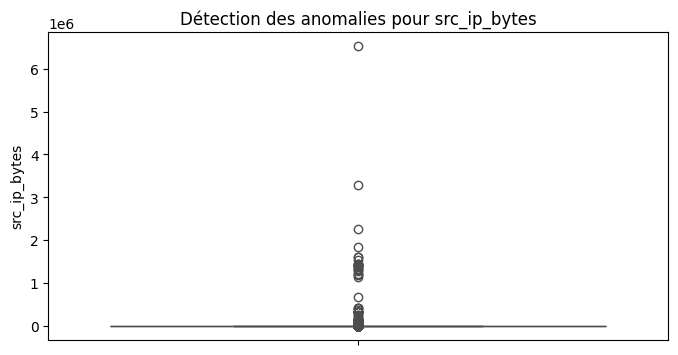

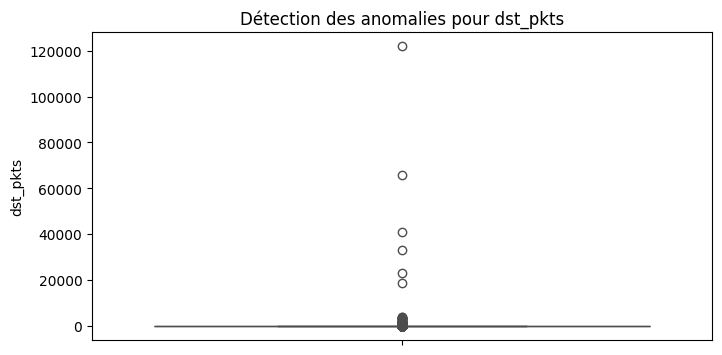

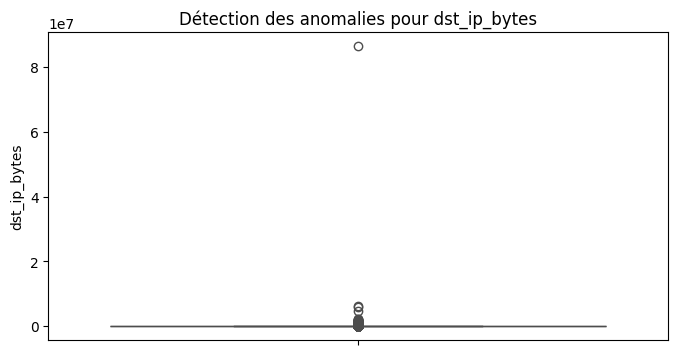

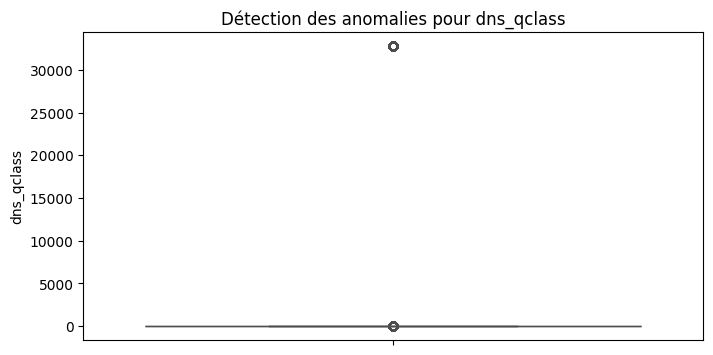

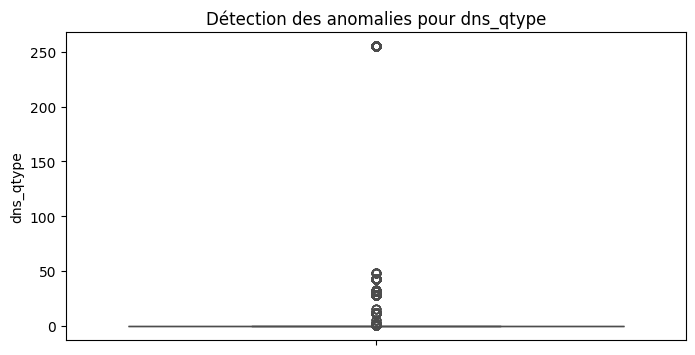

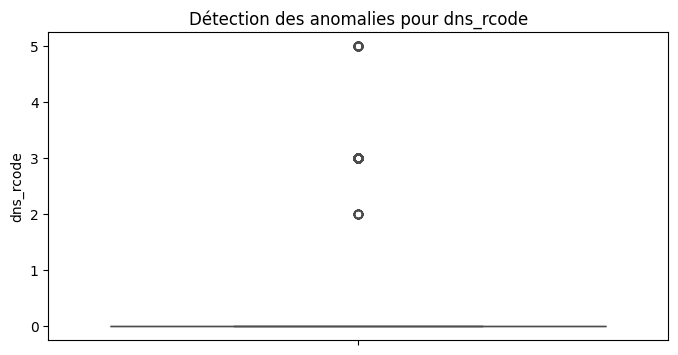

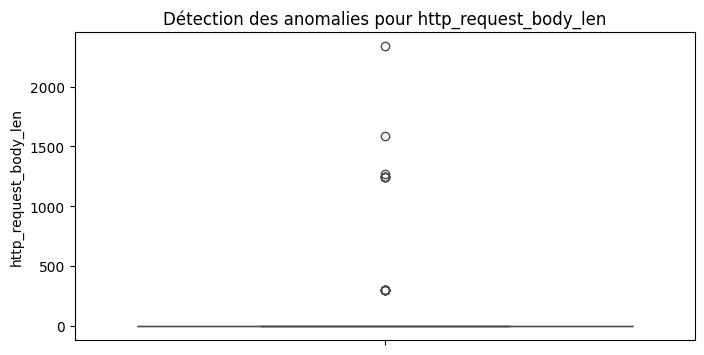

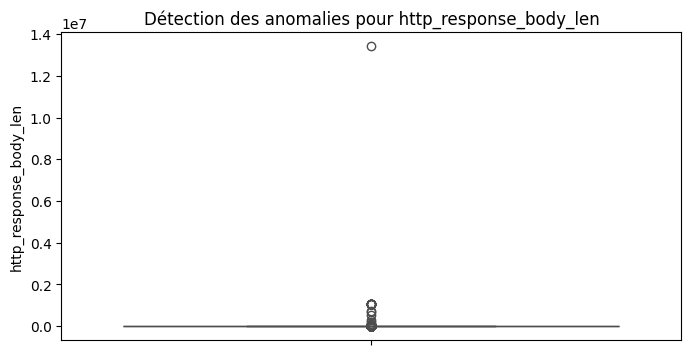

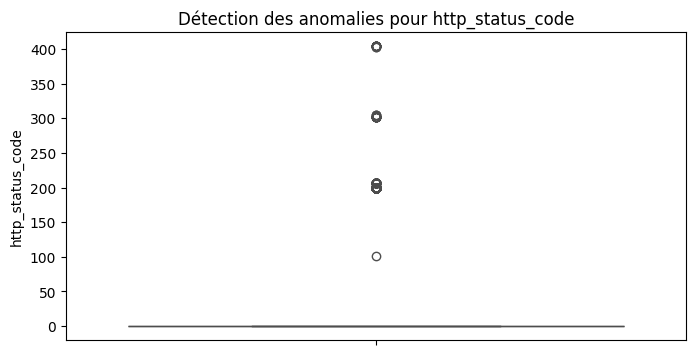

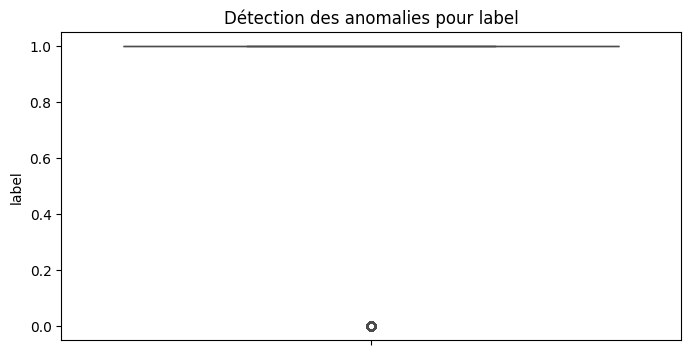

In [ ]:
#Détection des anomalies
for col in numeric.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data[col], color='orange')
    plt.title(f'Détection des anomalies pour {col}')
    plt.show()


<ipython-input-4-57dc1a3ef163>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='duration', palette="Set2")


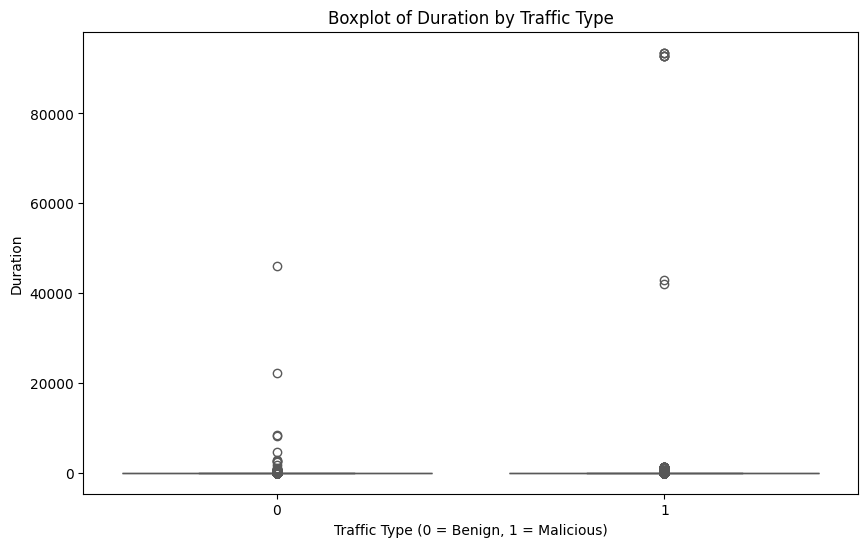

<ipython-input-4-57dc1a3ef163>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='src_bytes', palette="Set2")


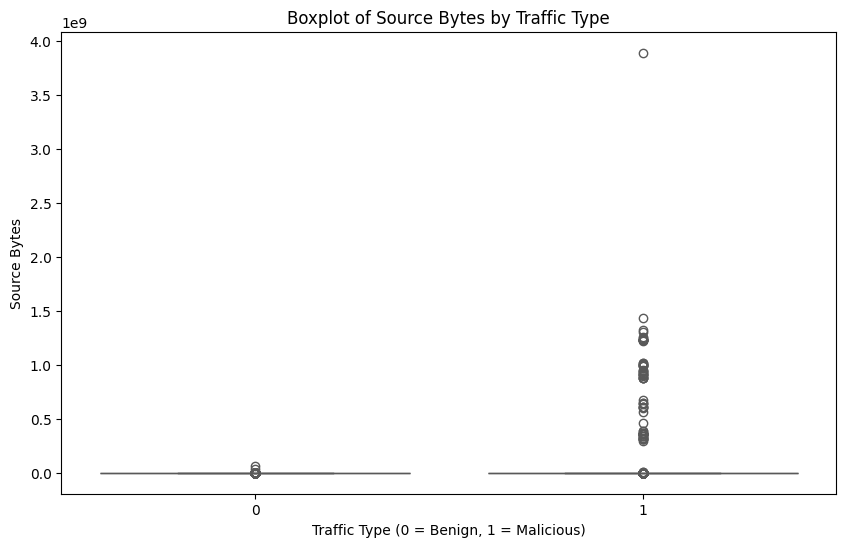

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for 'duration' vs target
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='label', y='duration', palette="Set2")
plt.title('Boxplot of Duration by Traffic Type')
plt.xlabel('Traffic Type (0 = Benign, 1 = Malicious)')
plt.ylabel('Duration')
plt.show()

# Boxplot for 'src_bytes' vs target
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='label', y='src_bytes', palette="Set2")
plt.title('Boxplot of Source Bytes by Traffic Type')
plt.xlabel('Traffic Type (0 = Benign, 1 = Malicious)')
plt.ylabel('Source Bytes')
plt.show()

# Add additional numerical features as needed (e.g., dst_bytes)


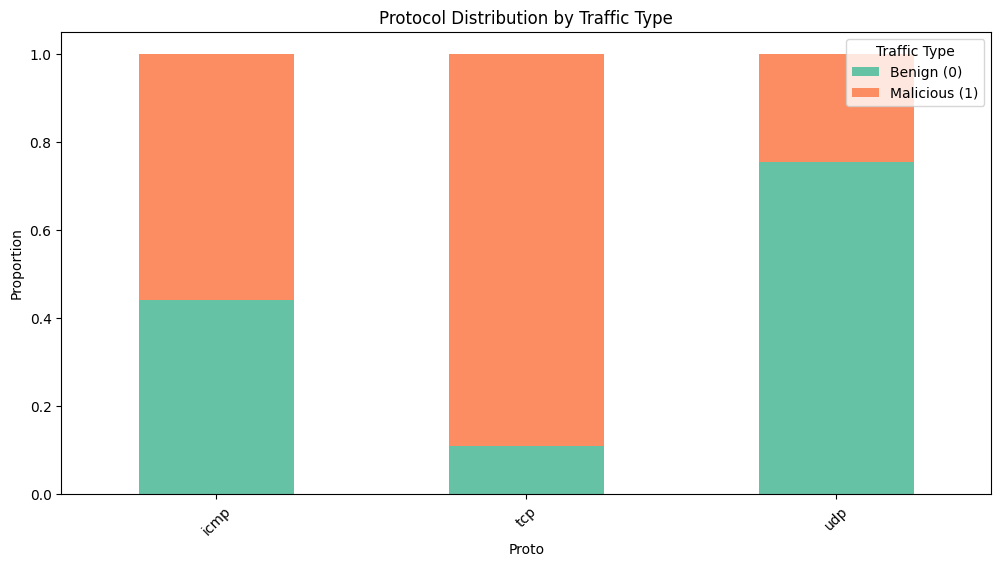

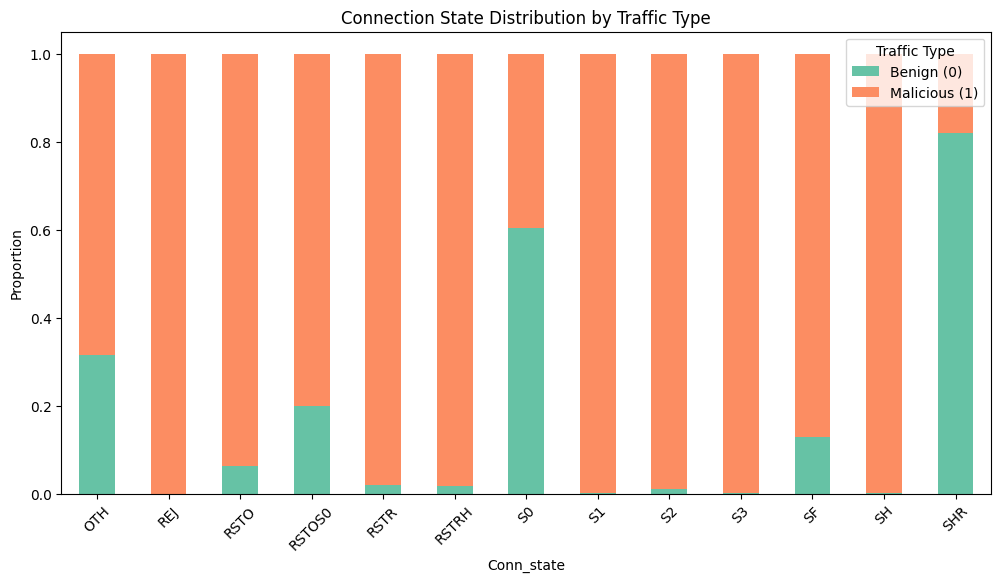

In [ ]:
import pandas as pd

# Helper function for stacked bar plots
def plot_stacked_bar(feature, title):
    feature_counts = data.groupby([feature, 'label']).size().unstack(fill_value=0)
    feature_counts_norm = feature_counts.div(feature_counts.sum(axis=1), axis=0)

    feature_counts_norm.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#66c2a5', '#fc8d62'])
    plt.title(title)
    plt.xlabel(feature.capitalize())
    plt.ylabel('Proportion')
    plt.legend(['Benign (0)', 'Malicious (1)'], title='Traffic Type')
    plt.xticks(rotation=45)
    plt.show()

# Stacked bar plot for 'proto'
plot_stacked_bar('proto', 'Protocol Distribution by Traffic Type')

# Stacked bar plot for 'conn_state'
plot_stacked_bar('conn_state', 'Connection State Distribution by Traffic Type')

# Add additional categorical features as needed (e.g., 'service')


Dans notre cas on a pas de données manquantes


Nous allons tout de même traiter les choix pour le traitement de ces valeurs manquantes.

---



In [ ]:

# Remplacer les tirets '-' par NaN dans tout le dataset
data.replace('-', np.nan, inplace=True)

# Vérifiez maintenant si les tirets ont bien été remplacés par NaN
print(data.isna().sum())


src_ip                         0
src_port                       0
dst_ip                         0
dst_port                       0
proto                          0
service                   132032
duration                       0
src_bytes                      0
dst_bytes                      0
conn_state                     0
missed_bytes                   0
src_pkts                       0
src_ip_bytes                   0
dst_pkts                       0
dst_ip_bytes                   0
dns_query                 176198
dns_qclass                     0
dns_qtype                      0
dns_rcode                      0
dns_AA                    176030
dns_RD                    176030
dns_RA                    176030
dns_rejected              176030
ssl_version               210642
ssl_cipher                210642
ssl_resumed               210642
ssl_established           210642
ssl_subject               211032
ssl_issuer                211032
http_trans_depth          210740
http_metho

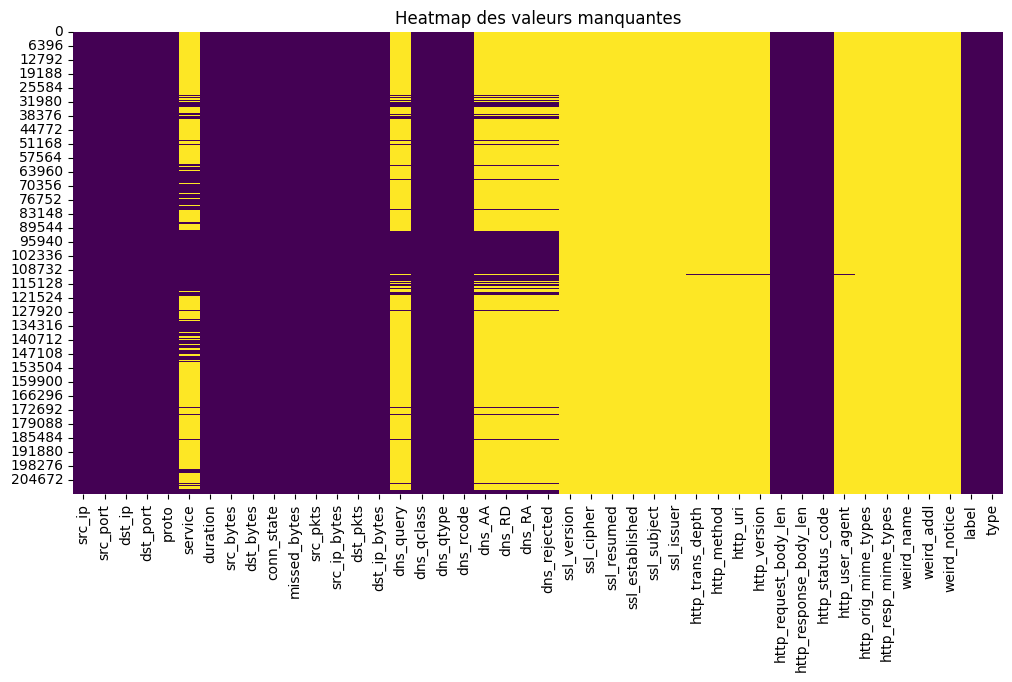

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap des valeurs manquantes
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Heatmap des valeurs manquantes")
plt.show()


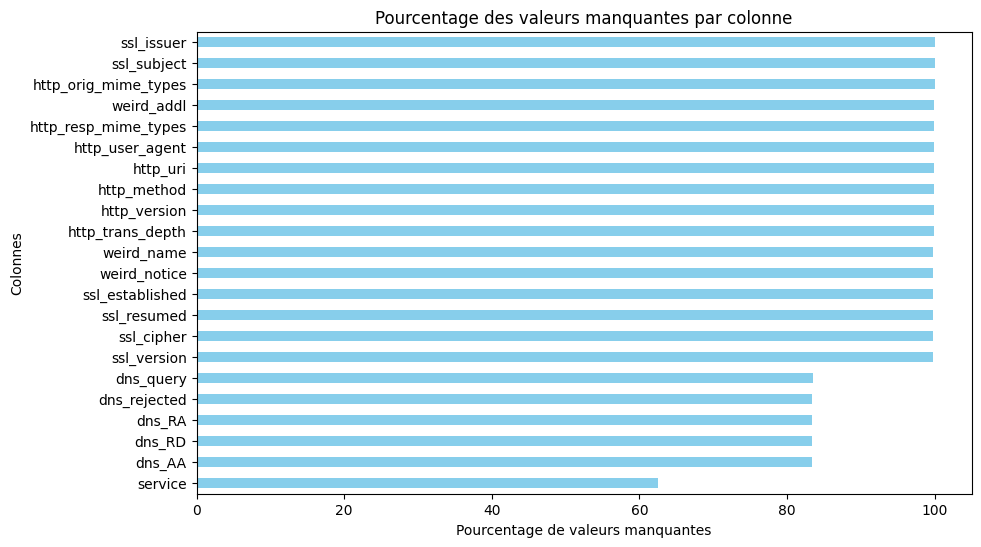

In [ ]:
# Calculer le pourcentage des valeurs manquantes
missing_percent = data.isnull().mean() * 100

# Filtrer les colonnes avec des valeurs manquantes
missing_percent = missing_percent[missing_percent > 0]

# Barplot des valeurs manquantes
plt.figure(figsize=(10, 6))
missing_percent.sort_values().plot(kind='barh', color='skyblue')
plt.title("Pourcentage des valeurs manquantes par colonne")
plt.xlabel("Pourcentage de valeurs manquantes")
plt.ylabel("Colonnes")
plt.show()


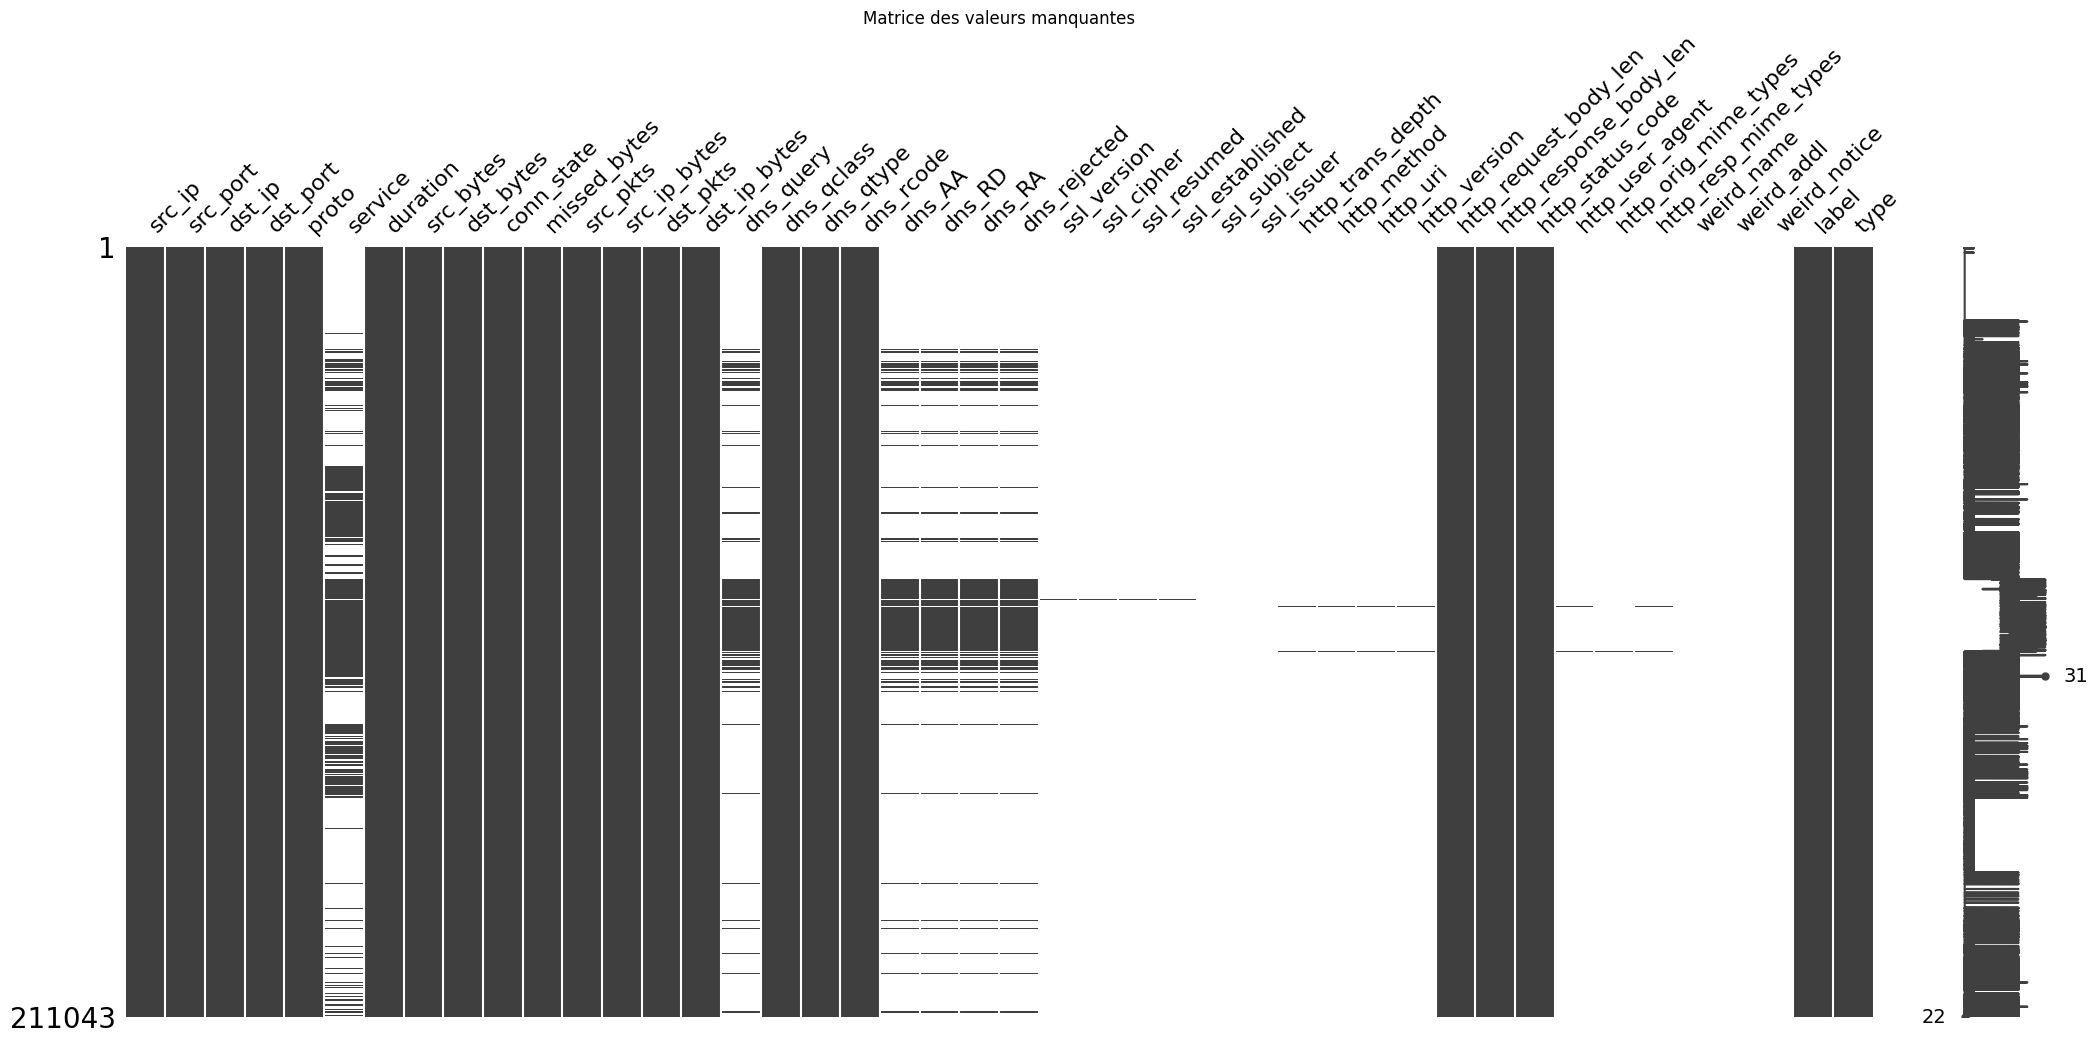

KeyboardInterrupt: 

In [ ]:
import missingno as msno

# Matrice des valeurs manquantes
msno.matrix(data)
plt.title("Matrice des valeurs manquantes")
plt.show()

# Heatmap des corrélations des valeurs manquantes
msno.heatmap(data)
plt.title("Corrélations des valeurs manquantes")
plt.show()


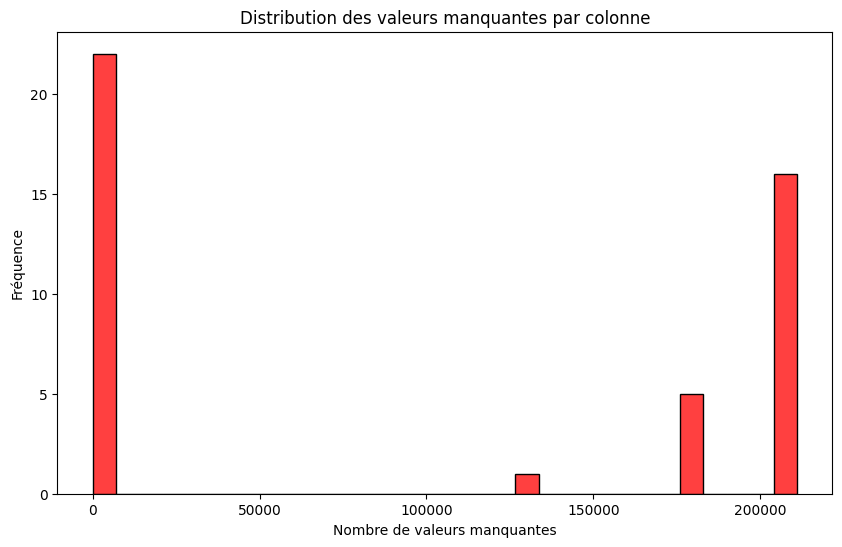

In [ ]:
# Compter les valeurs manquantes par colonne
missing_by_column = data.isnull().sum()

# Visualisation
plt.figure(figsize=(10, 6))
sns.histplot(missing_by_column, bins=30, kde=False, color='red')
plt.title("Distribution des valeurs manquantes par colonne")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Fréquence")
plt.show()


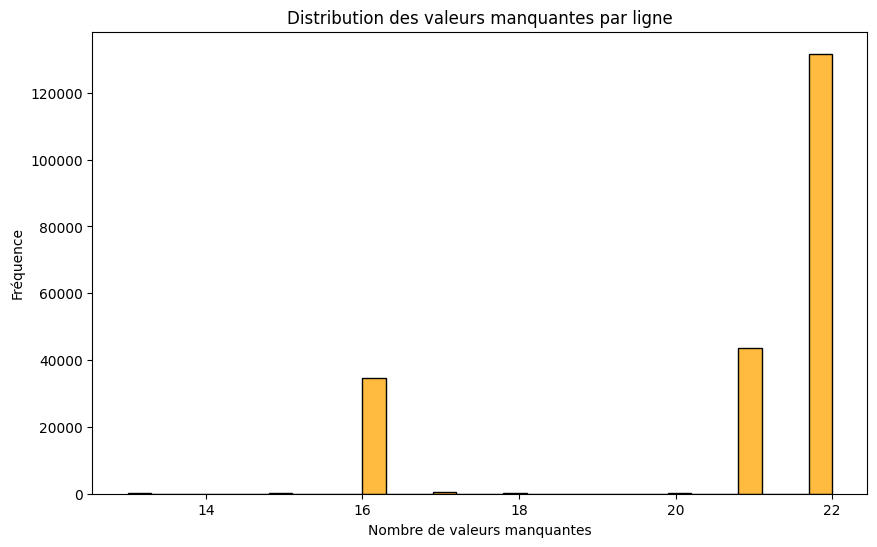

In [ ]:
# Compter les valeurs manquantes par ligne
missing_by_row = data.isnull().sum(axis=1)

# Visualisation
plt.figure(figsize=(10, 6))
sns.histplot(missing_by_row, bins=30, kde=False, color='orange')
plt.title("Distribution des valeurs manquantes par ligne")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Fréquence")
plt.show()


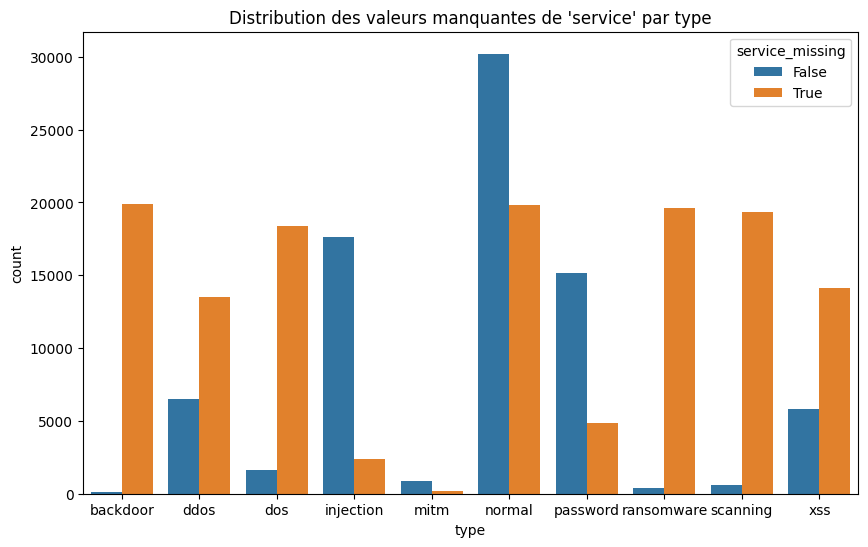

In [ ]:
# Exemple : analyser la distribution des valeurs manquantes de 'service' en fonction de 'type'
data['service_missing'] = data['service'].isnull()

plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='type', hue='service_missing')
plt.title("Distribution des valeurs manquantes de 'service' par type")
plt.show()


In [ ]:
import pandas as pd

# Vérifier les colonnes numériques et catégorielles
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = data.select_dtypes(include=['object']).columns

# Remplacer les valeurs manquantes pour les colonnes numériques par la médiane
for col in numerical_columns:
    median_value = data[col].median()
    data[col].fillna(median_value, inplace=True)
    print(f"Valeurs manquantes de la colonne numérique '{col}' remplacées par la médiane : {median_value}")

# Remplacer les valeurs manquantes pour les colonnes catégorielles par le mode
for col in categorical_columns:
    mode_value = data[col].mode()[0]
    data[col].fillna(mode_value, inplace=True)
    print(f"Valeurs manquantes de la colonne catégorielle '{col}' remplacées par le mode : {mode_value}")

# Vérifier s'il reste des valeurs manquantes
print("\nRésumé des valeurs manquantes après traitement :\n")
print(data.isnull().sum())


<ipython-input-5-c058dae4b65f>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(median_value, inplace=True)
<ipython-input-5-c058dae4b65f>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

Valeurs manquantes de la colonne numérique 'src_port' remplacées par la médiane : 44754.0
Valeurs manquantes de la colonne numérique 'dst_port' remplacées par la médiane : 80.0
Valeurs manquantes de la colonne numérique 'duration' remplacées par la médiane : 0.00017
Valeurs manquantes de la colonne numérique 'src_bytes' remplacées par la médiane : 0.0
Valeurs manquantes de la colonne numérique 'dst_bytes' remplacées par la médiane : 0.0
Valeurs manquantes de la colonne numérique 'missed_bytes' remplacées par la médiane : 0.0
Valeurs manquantes de la colonne numérique 'src_pkts' remplacées par la médiane : 1.0
Valeurs manquantes de la colonne numérique 'src_ip_bytes' remplacées par la médiane : 82.0
Valeurs manquantes de la colonne numérique 'dst_pkts' remplacées par la médiane : 1.0
Valeurs manquantes de la colonne numérique 'dst_ip_bytes' remplacées par la médiane : 40.0
Valeurs manquantes de la colonne numérique 'dns_qclass' remplacées par la médiane : 0.0
Valeurs manquantes de la co

In [ ]:
# Détection des outliers avec l'IQR
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Définir les bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifier les outliers
outliers = (data[numeric_columns] < lower_bound) | (data[numeric_columns] > upper_bound)
print("Nombre d'outliers par colonne :\n", outliers.sum())


Nombre d'outliers par colonne :
 src_port                  39337
dst_port                  40690
duration                  47670
src_bytes                 12426
dst_bytes                 43158
missed_bytes               2945
src_pkts                  15412
src_ip_bytes              21624
dst_pkts                  24273
dst_ip_bytes              43437
dns_qclass                34768
dns_qtype                 34768
dns_rcode                  8699
http_request_body_len        16
http_response_body_len      277
http_status_code            298
label                     50000
dtype: int64


Nombre d'outliers avant transformation par colonne :
 src_port                  39337
dst_port                  40690
duration                  47670
src_bytes                 12426
dst_bytes                 43158
missed_bytes               2945
src_pkts                  15412
src_ip_bytes              21624
dst_pkts                  24273
dst_ip_bytes              43437
dns_qclass                34768
dns_qtype                 34768
dns_rcode                  8699
http_request_body_len        16
http_response_body_len      277
http_status_code            298
dtype: int64


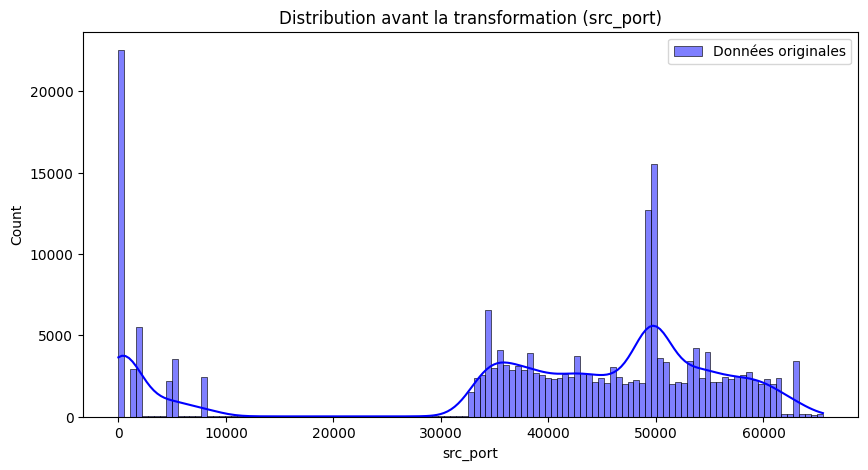

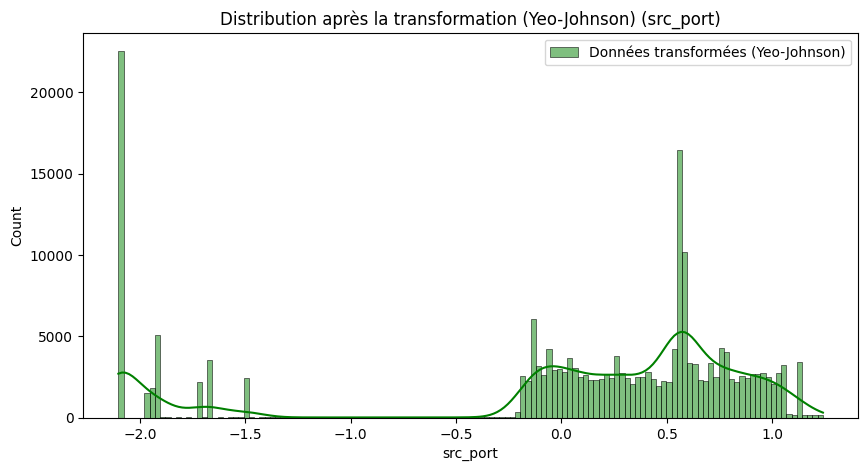


Nombre d'outliers après transformation par colonne :
 src_port                  39468
dst_port                    402
duration                  46120
src_bytes                     0
dst_bytes                     0
missed_bytes               2945
src_pkts                      0
src_ip_bytes              17919
dst_pkts                      0
dst_ip_bytes                  0
dns_qclass                34768
dns_qtype                 34768
dns_rcode                  8699
http_request_body_len        16
http_response_body_len      277
http_status_code            298
dtype: int64

Nombre d'outliers après capping par colonne :
 src_port                      0
dst_port                    402
duration                  52165
src_bytes                     0
dst_bytes                     0
missed_bytes                  0
src_pkts                      0
src_ip_bytes              17919
dst_pkts                      0
dst_ip_bytes                  0
dns_qclass                    0
dns_qtype           

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import seaborn as sns
import matplotlib.pyplot as plt

# Étape 1 : Détection des outliers avec IQR avant transformation
# Exclure la colonne 'label' du calcul des outliers
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
numeric_columns = [col for col in numeric_columns if col != 'label']  # Exclure 'label'

Q1 = data[numeric_columns].quantile(0.25)
Q3 = data[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Définir les bornes
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifier les outliers avant transformation
outliers_before = (data[numeric_columns] < lower_bound) | (data[numeric_columns] > upper_bound)
print("Nombre d'outliers avant transformation par colonne :\n", outliers_before.sum())

# Étape 2 : Appliquer Yeo-Johnson
# Créer une copie pour préserver les données originales
data_transformed = data.copy()

# Initialiser le PowerTransformer (Yeo-Johnson)
transformer = PowerTransformer(method='yeo-johnson')

# Appliquer la transformation colonne par colonne
for col in numeric_columns:
    # Ignorer les colonnes qui contiennent des valeurs nulles ou constantes
    if data[col].nunique() > 1:
        reshaped_data = data[[col]].values  # Transformer en array 2D
        data_transformed[col] = transformer.fit_transform(reshaped_data)

# Étape 3 : Visualisation avant et après la transformation pour une colonne
col_to_plot = numeric_columns[0]  # Vous pouvez changer cette valeur
plt.figure(figsize=(10, 5))
sns.histplot(data[col_to_plot], kde=True, color='blue', label='Données originales')
plt.legend()
plt.title(f"Distribution avant la transformation ({col_to_plot})")

plt.figure(figsize=(10, 5))
sns.histplot(data_transformed[col_to_plot], kde=True, color='green', label='Données transformées (Yeo-Johnson)')
plt.legend()
plt.title(f"Distribution après la transformation (Yeo-Johnson) ({col_to_plot})")
plt.show()

# Étape 4 : Détection des outliers sur les données transformées
Q1_transformed = data_transformed[numeric_columns].quantile(0.25)
Q3_transformed = data_transformed[numeric_columns].quantile(0.75)
IQR_transformed = Q3_transformed - Q1_transformed

# Définir les bornes sur les données transformées
lower_bound_transformed = Q1_transformed - 1.5 * IQR_transformed
upper_bound_transformed = Q3_transformed + 1.5 * IQR_transformed

# Identifier les outliers après transformation
outliers_after_transformation = (data_transformed[numeric_columns] < lower_bound_transformed) | (data_transformed[numeric_columns] > upper_bound_transformed)
print("\nNombre d'outliers après transformation par colonne :\n", outliers_after_transformation.sum())

# Étape 5 : Appliquez le capping sur les données transformées
data_capped = data_transformed.copy()

# Si la colonne 'label' existe, on la supprime avant de faire le capping
if 'label' in data_capped.columns:
    data_capped = data_capped.drop(columns='label')

# Appliquer le capping sur les colonnes numériques
for col in numeric_columns:
    data_capped[col] = data_capped[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# Étape 6 : Détection des outliers après capping
Q1_capped = data_capped[numeric_columns].quantile(0.25)
Q3_capped = data_capped[numeric_columns].quantile(0.75)
IQR_capped = Q3_capped - Q1_capped

# Définir les bornes sur les données après capping
lower_bound_capped = Q1_capped - 1.5 * IQR_capped
upper_bound_capped = Q3_capped + 1.5 * IQR_capped

# Identifier les outliers après capping
outliers_after_capping = (data_capped[numeric_columns] < lower_bound_capped) | (data_capped[numeric_columns] > upper_bound_capped)
print("\nNombre d'outliers après capping par colonne :\n", outliers_after_capping.sum())

# Vérification des résultats après capping
print("\nPremières lignes des données après capping :\n")
print(data_capped.head())


In [ ]:
import ipaddress
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Assuming `data_capped` is your DataFrame and `val_cat` contains the categorical columns
data_encoded = data_capped.copy()

# Define the IP address columns to be binary encoded
ip_address_cols = ['src_ip', 'dst_ip']

# Define the function for binary encoding IP addresses
def binary_encode_ip(ip):
    try:
        ip_obj = ipaddress.ip_address(ip)
        binary_str = bin(int(ip_obj))[2:]  # Convert to binary and remove '0b'
        if ip_obj.version == 4:  # IPv4
            return binary_str.zfill(32)  # Ensure it's 32 bits
        elif ip_obj.version == 6:  # IPv6
            return binary_str.zfill(128)  # Ensure it's 128 bits
    except ValueError:
        # Handle invalid IP addresses by returning None
        return None

# Apply binary encoding for each IP column
for ip_col in ip_address_cols:
    # Binary encode each IP address
    data_encoded[ip_col] = data_encoded[ip_col].apply(binary_encode_ip)

    # Determine the maximum bit length in the column (IPv4: 32, IPv6: 128)
    max_bit_length = data_encoded[ip_col].dropna().apply(len).max()

    # Split the binary strings into individual bit columns
    binary_columns = pd.DataFrame(
        data_encoded[ip_col].dropna().apply(lambda x: list(map(int, x.zfill(max_bit_length)))).to_list(),
        columns=[f"{ip_col}_bit_{i}" for i in range(max_bit_length)],
        index=data_encoded[ip_col].dropna().index
    )

    # Add the binary columns to the DataFrame
    data_encoded = pd.concat([data_encoded.drop(columns=ip_col), binary_columns], axis=1)

# Define the column(s) to be label encoded
# Define the column(s) to always use label encoding (e.g., binary or specific categories)
force_label_encode_cols = ['type']  # Example of forced label encoding columns

# Identify categorical columns
val_cat = data_encoded.select_dtypes(include=('object')) # Update this with the names of your categorical columns

# Separate categorical columns based on encoding strategies
label_encoded_cols = [col for col in val_cat if data_capped[col].nunique() <= 2 or col in force_label_encode_cols]
one_hot_encoded_cols = [col for col in val_cat if col not in label_encoded_cols]

# Apply label encoding for specified columns
for col in label_encoded_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_capped[col])
    if data_encoded[col].dtype == 'bool':  # Check for boolean dtype
        data_encoded[col] = data_encoded[col].astype(int)

# Apply one-hot encoding for remaining categorical columns
data_encoded = pd.get_dummies(data_encoded, columns=one_hot_encoded_cols, prefix=one_hot_encoded_cols)

# Output the transformed data
print("Transformed Data Summary:")
print(f"Label Encoded Columns: {label_encoded_cols}")
print(f"One-Hot Encoded Columns: {one_hot_encoded_cols}")
print("Sample Transformed Data:")
print(data_encoded.head())


Transformed Data Summary:
Label Encoded Columns: ['dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_resumed', 'ssl_established', 'http_version', 'http_orig_mime_types', 'weird_addl', 'weird_notice', 'type']
One-Hot Encoded Columns: ['proto', 'service', 'conn_state', 'dns_query', 'ssl_version', 'ssl_cipher', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_user_agent', 'http_resp_mime_types', 'weird_name']
Sample Transformed Data:
   src_port  dst_port  duration  src_bytes  dst_bytes  missed_bytes  src_pkts  \
0    9820.5  1.788420  0.135489   1.707259   1.655624           0.0  2.203293   
1    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
2    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
3    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
4    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   

   src_ip_bytes  dst_pkts  dst_ip_bytes  ... 

In [ ]:
# Convert all boolean columns in the current DataFrame (data_encoded) to 0 and 1
for col in data_encoded.select_dtypes(include=['bool']).columns:
    data_encoded[col] = data_encoded[col].astype(int)

# Display the updated DataFrame
print("Updated DataFrame with Boolean Columns Transformed:")
print(data_encoded.head())


Updated DataFrame with Boolean Columns Transformed:
   src_port  dst_port  duration  src_bytes  dst_bytes  missed_bytes  src_pkts  \
0    9820.5  1.788420  0.135489   1.707259   1.655624           0.0  2.203293   
1    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
2    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
3    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   
4    9820.5  1.493945 -0.081293  -0.724014  -0.640947           0.0 -0.464280   

   src_ip_bytes  dst_pkts  dst_ip_bytes  ...  weird_name_DNS_RR_unknown_type  \
0      4.377982  2.089418      1.552348  ...                               1   
1     -0.415698  0.238014      0.265700  ...                               1   
2     -0.415698  0.238014      0.265700  ...                               1   
3     -0.455241  0.238014      0.265700  ...                               1   
4     -0.415698  0.238014      0.265700  ...                 

In [ ]:
from sklearn.preprocessing import MinMaxScaler



# Étape 7 : Normalisation des données après capping
# Initialiser le scaler MinMaxScaler
scaler = MinMaxScaler()

# Appliquer la normalisation uniquement sur les colonnes numériques
data_normalized = data_encoded.copy()
print(data_encoded.describe())
data_normalized[numeric_columns] = scaler.fit_transform(data_encoded[numeric_columns])

# Étape 8 : Vérification des résultats après normalisation
print("\nPremières lignes des données normalisées :\n")
print(data_normalized.head())

# Vérification des plages de valeurs après normalisation
print("\nStatistiques des colonnes normalisées :\n")
print(data_normalized[numeric_columns].describe())


       src_port      dst_port       duration     src_bytes     dst_bytes  \
count  211043.0  2.110430e+05  211043.000000  2.110430e+05  2.110430e+05   
mean     9820.5 -7.886427e-16      -0.028838  8.619046e-17 -2.154762e-18   
std         0.0  1.000002e+00       0.092434  1.000002e+00  1.000002e+00   
min      9820.5 -7.180933e+00      -0.081293 -7.240142e-01 -6.409466e-01   
25%      9820.5 -6.417828e-01      -0.081293 -7.240142e-01 -6.409466e-01   
50%      9820.5 -4.799277e-01      -0.081293 -7.240142e-01 -6.409466e-01   
75%      9820.5  9.826660e-01      -0.081293  1.354836e+00  1.379559e+00   
max      9820.5  1.822738e+00       0.135489  1.736880e+00  1.745800e+00   

       missed_bytes      src_pkts  src_ip_bytes      dst_pkts  dst_ip_bytes  \
count      211043.0  2.110430e+05  2.110430e+05  2.110430e+05  2.110430e+05   
mean            0.0 -4.891309e-16 -1.142024e-16  5.817856e-17 -1.637619e-16   
std             0.0  1.000002e+00  1.000002e+00  1.000002e+00  1.000002e+00   

In [ ]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Columns: 1200 entries, src_port to weird_name_possible_split_routing
dtypes: float64(16), int64(1184)
memory usage: 1.9 GB


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize the data (important for PCA)

pca = PCA()
pca.fit(data_encoded)

# Step 3: Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Step 4: Cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Step 5: Limit to first 50 components
max_components = 43
explained_variance_ratio_limited = explained_variance_ratio[:max_components]
cumulative_explained_variance_limited = cumulative_explained_variance[:max_components]
components = range(1, min(len(explained_variance_ratio_limited), max_components) + 1)

# Step 6: Plot explained variance and cumulative explained variance


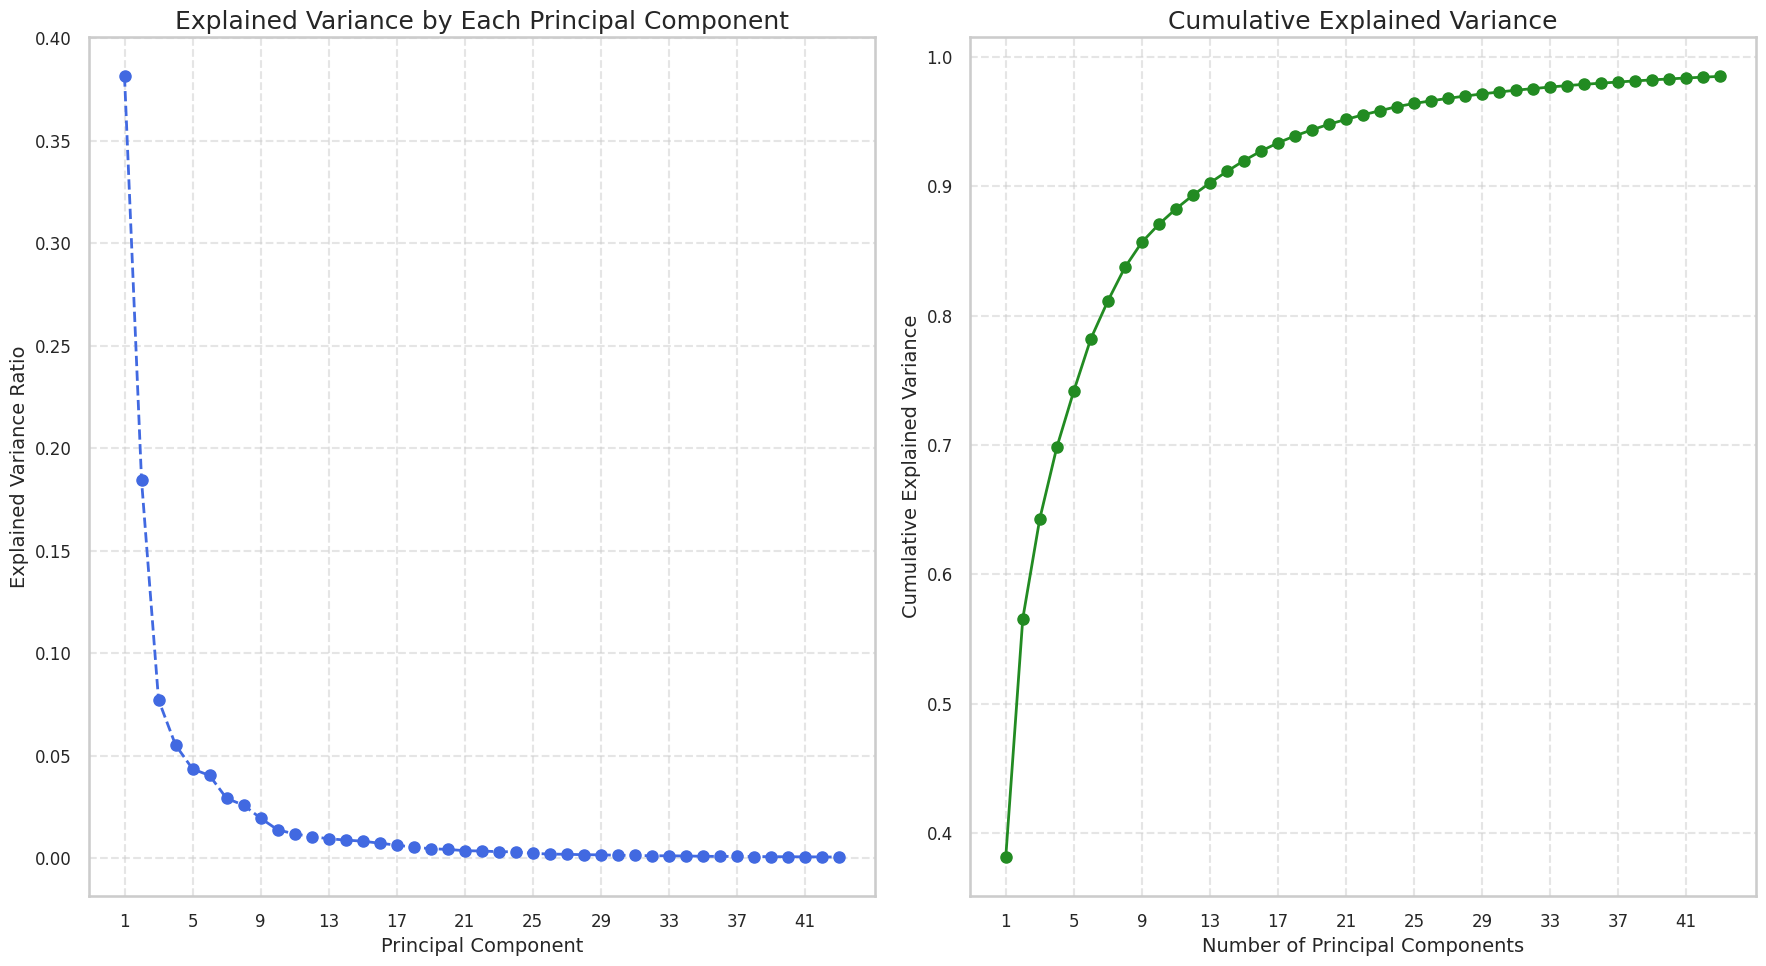

Optimal number of components to explain at least 90% variance: 13


In [ ]:
import seaborn as sns

# Set style for the plots
sns.set(style="whitegrid", context="talk")

# Create figure with larger size
plt.figure(figsize=(18, 10))

# Plot explained variance ratio
plt.subplot(1, 2, 1)
plt.plot(
    components, explained_variance_ratio_limited,
    marker='o', linestyle='--', color='royalblue', linewidth=2, markersize=8
)
plt.title('Explained Variance by Each Principal Component', fontsize=18)
plt.xlabel('Principal Component', fontsize=14)
plt.ylabel('Explained Variance Ratio', fontsize=14)
plt.xticks(
    range(1, len(components) + 1, max(1, len(components) // 10)),  # Space out x-axis ticks
    fontsize=12
)
plt.yticks(fontsize=12)
plt.grid(alpha=0.5, linestyle='--')

# Plot cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(
    components, cumulative_explained_variance_limited,
    marker='o', linestyle='-', color='forestgreen', linewidth=2, markersize=8
)
plt.title('Cumulative Explained Variance', fontsize=18)
plt.xlabel('Number of Principal Components', fontsize=14)
plt.ylabel('Cumulative Explained Variance', fontsize=14)
plt.xticks(
    range(1, len(components) + 1, max(1, len(components) // 10)),  # Space out x-axis ticks
    fontsize=12
)
plt.yticks(fontsize=12)
plt.grid(alpha=0.5, linestyle='--')

# Adjust layout
plt.tight_layout()
plt.show()

# Step 7: Decide the number of components based on the cumulative explained variance
# For example, choose components that explain at least 90% of the variance
n_components = np.argmax(cumulative_explained_variance >= 0.90) + 1
print(f'Optimal number of components to explain at least 90% variance: {n_components}')


In [ ]:
# Step 7: Apply PCA with the optimal number of components
pca = PCA(n_components=n_components)
reduced_data = pca.fit_transform(data_encoded)

# Step 8: Create a DataFrame with the reduced data
reduced_df = pd.DataFrame(reduced_data, columns=[f'PC{i+1}' for i in range(n_components)])

# Step 9: Visualize the reduced data (if 2 or 3 components)
if n_components == 2:
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced_df['PC1'], reduced_df['PC2'], alpha=0.7)
    plt.title('PCA - 2D Visualization')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()
elif n_components == 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(reduced_df['PC1'], reduced_df['PC2'], reduced_df['PC3'], alpha=0.7)
    ax.set_title('PCA - 3D Visualization')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_zlabel('Principal Component 3')
    plt.show()

# Optional: You can also check the explained variance for the selected components
explained_variance_selected = pca.explained_variance_ratio_
print(f'Explained Variance for each selected component: {explained_variance_selected}')
print(f'Cumulative Explained Variance: {np.cumsum(explained_variance_selected)}')


Explained Variance for each selected component: [0.3813313  0.18441782 0.07723613 0.05522639 0.04357254 0.04037268
 0.02921032 0.02591681 0.01954613 0.01389178 0.01186709 0.01058787
 0.00952305]
Cumulative Explained Variance: [0.3813313  0.56574912 0.64298525 0.69821164 0.74178417 0.78215686
 0.81136718 0.83728399 0.85683012 0.8707219  0.88258899 0.89317686
 0.90269991]


In [ ]:
reduced_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-4.942348,2.743070,3.614345,3.015728,0.574497,0.607398,0.155344,0.052981,-0.194954,-0.326908,1.725770,-0.582513,-1.233367
1,-4.320683,-2.614497,0.383490,1.675738,-0.168404,0.623743,1.266063,-0.285813,-0.140096,0.172580,-0.343353,0.180948,0.126664
2,-4.320683,-2.614497,0.383490,1.675738,-0.168404,0.623743,1.266063,-0.285813,-0.140096,0.172580,-0.343353,0.180948,0.126664
3,-4.320232,-2.625003,0.359465,1.672911,-0.167048,0.627324,1.269186,-0.282078,-0.135376,0.174795,-0.343635,0.186329,0.130823
4,-4.320683,-2.614497,0.383490,1.675738,-0.168404,0.623743,1.266063,-0.285813,-0.140096,0.172580,-0.343353,0.180948,0.126664


In [ ]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   PC1     211043 non-null  float64
 1   PC2     211043 non-null  float64
 2   PC3     211043 non-null  float64
 3   PC4     211043 non-null  float64
 4   PC5     211043 non-null  float64
 5   PC6     211043 non-null  float64
 6   PC7     211043 non-null  float64
 7   PC8     211043 non-null  float64
 8   PC9     211043 non-null  float64
 9   PC10    211043 non-null  float64
 10  PC11    211043 non-null  float64
 11  PC12    211043 non-null  float64
 12  PC13    211043 non-null  float64
dtypes: float64(13)
memory usage: 20.9 MB


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
y = data["label"]

# Step 1: Reduce the dataset to 50% of the original data
data_reduced = data.sample(frac=0.5, random_state=42)
data_normalized_reduced = data_normalized.loc[data_reduced.index]

# Step 2: Train-test split for reduced data (50% train and 50% test)
X_train, X_test, y_train, y_test = train_test_split(data_normalized_reduced, y.loc[data_reduced.index], test_size=0.5, random_state=42)

# Baseline model
baseline_model = XGBClassifier(random_state=42)
# Get the current column names
current_columns = X_train.columns

# Replace any forbidden characters with underscores
new_columns = [col.replace('[', '_').replace(']', '_').replace('<', '_') for col in current_columns]

# Assign the new column names to the DataFrame
X_train.columns = new_columns
X_test.columns = new_columns

# Now you can fit the model
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Step 6: Evaluate models
print("Baseline Model Report:")
print(classification_report(y_test, y_pred_baseline))


Baseline Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12522
           1       1.00      1.00      1.00     40239

    accuracy                           1.00     52761
   macro avg       1.00      1.00      1.00     52761
weighted avg       1.00      1.00      1.00     52761



In [ ]:
y = data["label"]

# Step 1: Train-test split for reduced_df and target
X_train, X_test, y_train, y_test = train_test_split(data_normalized, y, test_size=0.3, random_state=42)

# Baseline model
baseline_model = XGBClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Step 6: Evaluate models
print("Baseline Model Report:")
print(classification_report(y_test, y_pred_baseline))

ValueError: feature_names must be string, and may not contain [, ] or <

In [ ]:
y = data["label"]

# Step 1: Train-test split for reduced_df and target
X_train, X_test, y_train, y_test = train_test_split(reduced_df, y, test_size=0.3, random_state=42)

# Step 2: Oversampling using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Step 3: Undersampling
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Step 4: Class weighting
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
scale_pos_weight = weights_dict[1]  # Assuming 1 is the minority class

# Step 5: Train XGBoost models
# Baseline model
baseline_model = XGBClassifier(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# SMOTE model
smote_model = XGBClassifier(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

# Undersampled model
undersampled_model = XGBClassifier(random_state=42)
undersampled_model.fit(X_train_under, y_train_under)
y_pred_under = undersampled_model.predict(X_test)

# Weighted model
weighted_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

# Step 6: Evaluate models
print("Baseline Model Report:")
print(classification_report(y_test, y_pred_baseline))

print("SMOTE Model Report:")
print(classification_report(y_test, y_pred_smote))

print("Undersampled Model Report:")
print(classification_report(y_test, y_pred_under))

print("Weighted Model Report:")
print(classification_report(y_test, y_pred_weighted))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida

Baseline Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15045
           1       1.00      1.00      1.00     48268

    accuracy                           1.00     63313
   macro avg       1.00      1.00      1.00     63313
weighted avg       1.00      1.00      1.00     63313

SMOTE Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15045
           1       1.00      1.00      1.00     48268

    accuracy                           1.00     63313
   macro avg       1.00      1.00      1.00     63313
weighted avg       1.00      1.00      1.00     63313

Undersampled Model Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15045
           1       1.00      1.00      1.00     48268

    accuracy                           1.00     63313
   macro avg       1.00      1.00      1.00     63313
weig

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
y = data_normalized["label"]
# Step 1: Train-test split for reduced_df and target
X_train, X_test, y_train, y_test = train_test_split(data_normalized, y, test_size=0.3, random_state=42)

# Step 2: Oversampling using SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Step 3: Undersampling
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Step 4: Class weighting
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
scale_pos_weight = weights_dict[1]  # Assuming 1 is the minority class

# Step 5: Train XGBoost models with reduced overfitting
params = {
    'learning_rate': 0.05,  # Lower learning rate to make the model more robust
    'max_depth': 4,  # Limit tree depth to prevent overfitting
    'subsample': 0.8,  # Use 80% of the data to train each tree
    'colsample_bytree': 0.8,  # Randomly sample 80% of features for each tree
    'reg_alpha': 0.1,  # L1 regularization (Lasso)
    'reg_lambda': 1.0,  # L2 regularization (Ridge)
    'scale_pos_weight': scale_pos_weight,  # Handle class imbalance
    'n_estimators': 100,  # Number of trees
    'random_state': 42
}

# Baseline model with regularization and other tweaks
baseline_model = XGBClassifier(**params)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# SMOTE model with regularization and other tweaks
smote_model = XGBClassifier(**params)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

# Undersampled model with regularization and other tweaks
undersampled_model = XGBClassifier(**params)
undersampled_model.fit(X_train_under, y_train_under)
y_pred_under = undersampled_model.predict(X_test)

# Weighted model with regularization and other tweaks
# `scale_pos_weight` is already in params, so it is passed only through params.
weighted_model = XGBClassifier(**params)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

# Step 6: Evaluate models
print("Baseline Model Report:")
print(classification_report(y_test, y_pred_baseline))

print("SMOTE Model Report:")
print(classification_report(y_test, y_pred_smote))

print("Undersampled Model Report:")
print(classification_report(y_test, y_pred_under))

print("Weighted Model Report:")
print(classification_report(y_test, y_pred_weighted))


NameError: name 'data_normalized' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Supposons que `reduced_df` est le DataFrame réduit (par exemple, après PCA)
# et que `y` est la colonne cible (label).
# Si ce n'est pas encore fait, remplacez `reduced_df` par vos données pertinentes.

# Étape 1: Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(reduced_df, y, test_size=0.3, random_state=42)

# Étape 2: Suréchantillonnage avec SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Étape 3: Sous-échantillonnage
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train, y_train)

# Étape 4: Calcul des poids des classes
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print("Class Weights:", weights_dict)

# Étape 5: Entraînement des modèles avec la régression logistique
# Modèle de base
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

# Modèle avec SMOTE
smote_model = LogisticRegression(random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

# Modèle sous-échantillonné
undersampled_model = LogisticRegression(random_state=42)
undersampled_model.fit(X_train_under, y_train_under)
y_pred_under = undersampled_model.predict(X_test)

# Modèle pondéré
weighted_model = LogisticRegression(class_weight='balanced', random_state=42)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

# Étape 6: Évaluation des modèles
print("Baseline Model Report:")
print(classification_report(y_test, y_pred_baseline))

print("SMOTE Model Report:")
print(classification_report(y_test, y_pred_smote))

print("Undersampled Model Report:")
print(classification_report(y_test, y_pred_under))

print("Weighted Model Report:")
print(classification_report(y_test, y_pred_weighted))


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.valida

Class Weights: {0: 2.1131454727506793, 1: 0.6549767235646198}
Baseline Model Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     15045
           1       0.99      0.99      0.99     48268

    accuracy                           0.98     63313
   macro avg       0.98      0.97      0.97     63313
weighted avg       0.98      0.98      0.98     63313

SMOTE Model Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     15045
           1       0.99      0.98      0.99     48268

    accuracy                           0.98     63313
   macro avg       0.97      0.98      0.98     63313
weighted avg       0.98      0.98      0.98     63313

Undersampled Model Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     15045
           1       0.99      0.98      0.99     48268

    accuracy                           0.98     63